In [19]:
%matplotlib inline

import os
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import matplotlib.lines as mlines
import matplotlib as mpl
import colorsys
import matplotlib.colors as mcolors

from eval_utils import load_model_results, lift_compression_args, include_peft, add_rank

from plot.color import Color
from plot.formatter import LabelFormatter, NumberFormatter, Scale, Grid, LambdaFormatter, Decorator, PercentFormatter

### Matplotlib configuration

In [20]:
plt.rcParams["text.usetex"] = False
mpl_params = {
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
}
plt.rcParams.update(mpl_params)

### Notebook parameters

In [21]:
results_file = "/home/neubauer/src/comp-economics/compression_results.json"
x_col = "total_params"
y_col = "compression_factor"
save_path = "plot.png"  # None to disable saving

### Load and normalize results

In [22]:
print(f"Loading results from {results_file}")
dict_results = load_model_results(results_file)

# Lift compression args and flatten structure
dict_results = {k: lift_compression_args(v).get("compression", {}) for k, v in dict_results.items()}

# Include PEFT info and ranking
dict_results = include_peft(dict_results)
dict_results = add_rank(dict_results)
print(f"Loaded {len(dict_results)} runs")

# Save normalized results for inspection
with open("loaded_results.json", "w") as f:
    json.dump(dict_results, f, indent=2)

print("Saved normalized results to loaded_results.json")

#TODO: handle quantized adapters

Loading results from /home/neubauer/src/comp-economics/compression_results.json
Loaded 11 runs
Saved normalized results to loaded_results.json


### Convert to DataFrame

In [23]:
df = pd.DataFrame.from_dict(dict_results, orient="index").reset_index().rename(columns={"index": "run_key"})
df = df.fillna(0)

# Standardize encoding names
df["encoding"] = df["encoding"].replace({"huffman": "HC", "bitpacked": "BP"})

# Convert mb columns to bytes for consistency
MB = 1024 * 1024
df["adapter_size_bytes"] = (df["adapter_size_mb"] * MB).astype(int)
df["base_model_size_bytes"] = (df["base_model_size_mb"] * MB).astype(int)

# remove mb columns to avoid confusion
df = df.drop(columns=["adapter_size_mb", "base_model_size_mb", "print_results", 'input_path', 'output_path', 'lora_path'])

In [24]:
# Fix datatypes of bytes by rounding up and converting to int
df["adapter_size_bytes"] = df["adapter_size_bytes"].astype(int)
df["base_model_size_bytes"] = df["base_model_size_bytes"].astype(int)
df["original_size_bytes"] = df["original_size_bytes"].astype(int)
df["arithmetic_code_size_bytes"] = df["arithmetic_code_size_bytes"].astype(int)
df["bitmap_size_bytes"] = df["bitmap_size_bytes"].astype(int)
df["final_size_bytes"] = df["final_size_bytes"].astype(int)

In [25]:
# --- Full list of known models ---
ALL_MODELS = [
    "Qwen/Qwen2.5-0.5B",
    "Qwen/Qwen2.5-3B",
    "Qwen/Qwen2.5-7B",
    "Qwen/Qwen3-0.6B",
    "Qwen/Qwen3-2B",
    "Qwen/Qwen3-4B",
    "gpt2",
    "google/flan-t5-small",
    "google/flan-t5-base",
    "google/flan-t5-large",
    "google/flan-t5-xl",
    "google/flan-t5-xxl",
    "meta-llama/Llama-3.2-1B-instruct",
    "state-spaces/mamba-130m-hf",
    "state-spaces/mamba-370m-hf",
    "state-spaces/mamba-790m-hf",
    "state-spaces/mamba-1.4b-hf",]
    
def clean_model_name(model):
    name = model.split("/")[-1]  # remove HF prefix

    name = name.replace("-hf", "")
    name = name.replace("-instruct", "")

    return name

def map_model_name(run_key):
    run_key_lower = run_key.lower()
    if "qwen2.5" in run_key_lower:
        model = next((m for m in ALL_MODELS if "qwen2.5" in m.lower()), "Unknown")
    elif "qwen3" in run_key_lower:
        model = next((m for m in ALL_MODELS if "qwen3" in m.lower()), "Unknown")
    elif "gpt2" in run_key_lower:
        model = "gpt2"
    elif "t5" in run_key_lower:
        model =  "t5"
    elif "mamba" in run_key_lower:
        model = next((m for m in ALL_MODELS if "mamba" in m.lower()), "Unknown")
    else:
        return "Unknown"
    return clean_model_name(model) if model else "Unknown"

df["model_name"] = df["run_key"].apply(map_model_name)

In [26]:
print(df.columns)
print(df['model_name'].unique())
df.head(10)

Index(['run_key', 'chunk_length', 'chunk_size', 'original_size_bytes',
       'arithmetic_code_size_bytes', 'bitmap_size_bytes', 'final_size_bytes',
       'pure_compression_factor', 'compression_factor', 'input_tokens_count',
       'entropy', 'total_compression_time', 'tokenize_time',
       'compression_time', 'inference_time', 'ac_time', 'data_copy_time',
       'softmax_time', 'throughput_tokens_per_sec',
       'throughput_kibibytes_per_sec', 'inference_throughput_tokens_per_sec',
       'inference_throughput_kibibytes_per_sec', 'total_params',
       'adapter_params', 'base_model_params', 'total_size_mb', 'mode',
       'model_name', 'context_length', 'retain_tokens', 'first_n_tokens',
       'use_kv_cache', 'text_input', 'reduce_tokens', 'batch_size', 'engine',
       'encoding', 'is_seq2seq', 'peft', 'rank', 'is_mamba',
       'adapter_size_bytes', 'base_model_size_bytes'],
      dtype='str')
<ArrowStringArray>
['Qwen2.5-0.5B', 'mamba-130m']
Length: 2, dtype: str


,run_key,chunk_length,chunk_size,original_size_bytes,arithmetic_code_size_bytes,bitmap_size_bytes,final_size_bytes,pure_compression_factor,compression_factor,input_tokens_count,...,reduce_tokens,batch_size,engine,encoding,is_seq2seq,peft,rank,is_mamba,adapter_size_bytes,base_model_size_bytes
0,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,6250,-1,532654,61241,10818,72059,8.697652,7.391902,53263600,...,True,16,transformer,AC,False,0,0,0,0,988062679
1,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,3125,-1,532654,61553,10818,72371,8.653478,7.359971,50373600,...,True,32,transformer,AC,False,0,0,0,0,988062679
2,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,1562,-1,532654,61908,10818,72726,8.603961,7.324121,45696192,...,True,64,transformer,AC,False,0,0,0,0,988062679
3,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,781,-1,532654,62607,10818,73425,8.507797,7.254322,39087488,...,True,128,transformer,AC,False,0,0,0,0,988062679
4,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,390,-1,532654,64683,10818,75501,8.234790,7.054891,19518720,...,True,256,transformer,AC,False,0,0,0,0,988062679
5,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,6250,-1,532654,70737,10818,81555,7.529996,6.531174,53263600,...,True,16,transformer,HC,False,0,0,0,0,988062679
6,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,3125,-1,532654,71153,10818,81971,7.486011,6.498059,50373600,...,True,32,transformer,HC,False,0,0,0,0,988062679
7,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,1562,-1,532654,71602,10818,82420,7.439055,6.462650,45696192,...,True,64,transformer,HC,False,0,0,0,0,988062679
8,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,781,-1,532654,72459,10818,83277,7.351020,6.396105,39087488,...,True,128,transformer,HC,False,0,0,False,0,988062679
9,text8:state-spaces/mamba-130m-hf|ctx=1000|ret=...,78,-1,53331,7253,4966,12219,7.352070,4.364284,394368,...,True,128,transformer,AC,False,0,0,True,0,516539023


In [27]:
df[['model_name', 'rank', 'peft', 'original_size_bytes', 'arithmetic_code_size_bytes', 'bitmap_size_bytes', 'adapter_size_bytes', 'base_model_size_bytes', 'final_size_bytes']].head(20)

,model_name,rank,peft,original_size_bytes,arithmetic_code_size_bytes,bitmap_size_bytes,adapter_size_bytes,base_model_size_bytes,final_size_bytes
0,Qwen2.5-0.5B,0,0,532654,61241,10818,0,988062679,72059
1,Qwen2.5-0.5B,0,0,532654,61553,10818,0,988062679,72371
2,Qwen2.5-0.5B,0,0,532654,61908,10818,0,988062679,72726
3,Qwen2.5-0.5B,0,0,532654,62607,10818,0,988062679,73425
4,Qwen2.5-0.5B,0,0,532654,64683,10818,0,988062679,75501
5,Qwen2.5-0.5B,0,0,532654,70737,10818,0,988062679,81555
6,Qwen2.5-0.5B,0,0,532654,71153,10818,0,988062679,81971
7,Qwen2.5-0.5B,0,0,532654,71602,10818,0,988062679,82420
8,Qwen2.5-0.5B,0,0,532654,72459,10818,0,988062679,83277
9,mamba-130m,0,0,53331,7253,4966,0,516539023,12219


In [28]:
df['pure_comp_factor'] = df['original_size_bytes'] / df['arithmetic_code_size_bytes']

df['total_bytes'] = df['arithmetic_code_size_bytes'] + df['bitmap_size_bytes'] + df['adapter_size_bytes']

print(df[['original_size_bytes', 'arithmetic_code_size_bytes', 'bitmap_size_bytes', 'adapter_size_bytes', 'final_size_bytes']].head(10))

df['eff_comp_factor'] = df['original_size_bytes'] / df['total_bytes']

   original_size_bytes  arithmetic_code_size_bytes  bitmap_size_bytes  \
0               532654                       61241              10818   
1               532654                       61553              10818   
2               532654                       61908              10818   
3               532654                       62607              10818   
4               532654                       64683              10818   
5               532654                       70737              10818   
6               532654                       71153              10818   
7               532654                       71602              10818   
8               532654                       72459              10818   
9                53331                        7253               4966   

   adapter_size_bytes  final_size_bytes  
0                   0             72059  
1                   0             72371  
2                   0             72726  
3                   0       

In [29]:
df[['total_bytes', 'pure_comp_factor', 'eff_comp_factor']].head(10)

,total_bytes,pure_comp_factor,eff_comp_factor
0,72059,8.697670,7.391915
1,72371,8.653583,7.360048
2,72726,8.603961,7.324121
3,73425,8.507898,7.254396
4,75501,8.234838,7.054926
5,81555,7.530062,6.531224
6,81971,7.486037,6.498079
7,82420,7.439094,6.462679
8,83277,7.351109,6.396172
9,12219,7.352957,4.364596


### Column labels & plotting mappings

In [ ]:
LABELS = {
    "total_params": "Model Parameters",
    "compression_factor": "Compression Ratio",
    "pure_compression_factor": "Pure Compression Ratio",
    "adapter_params": "Adapter Parameters",
    "base_model_params": "Base Model Parameters",
    "base_model_size_mb": "Base Model Size (MB)",
    "adapter_size_mb": "Adapter Size (MB)",
    "throughput_kibibytes_per_sec": "Compression Throughput (KiB/s)",
    "final_size_bytes": "Compressed Size (bytes)",
    "peft": "PEFT Method",
    "encoding": "Encoding Method",
    "rank": "Rank (r) of Adapters (if applicable)",
}

SCALES = {
    "total_params": "log",
    "throughput_kibibytes_per_sec": "log",
    "final_size_bytes": "log",
}

# PEFT and encoding mappings (unchanged)
COLOR_BY_PEFT = {None: "tab:gray", 
                 "lora": "tab:blue", 
                 "vera": "tab:orange"}
MARKER_BY_ENCODING = {"AC": "o", "HC": "s", "BP": "D", None: "x"}

# --- Assign colors dynamically by model family ---
COLOR_BY_MODEL = {}
for model in ALL_MODELS:
    if model.startswith("Qwen2.5") or model.startswith("Qwen/Qwen2.5"):
        COLOR_BY_MODEL[model] = "tab:blue"
    elif model.startswith("Qwen3") or model.startswith("Qwen/Qwen3"):
        COLOR_BY_MODEL[model] = "tab:green"
    elif model.startswith("gpt2"):
        COLOR_BY_MODEL[model] = "tab:orange"
    elif model.startswith("flan-t5") or model.startswith("t5"):
        COLOR_BY_MODEL[model] = "tab:purple"
    elif model.startswith("mamba"):
        COLOR_BY_MODEL[model] = "tab: pink"
    elif model.startswith("Unknown"):
        COLOR_BY_MODEL[model] = "tab:gray"
    else:
        COLOR_BY_MODEL[model] = "tab:gray"  # fallback

def pretty_label(col):
    return LABELS.get(col, col.replace("_", " ").title())

def normalize_marker_sizes(series, min_size=25, max_size=200):
    val_min, val_max = series.min(), series.max()
    return min_size + (max_size - min_size) * (series - val_min) / (val_max - val_min + 1e-9)

#--- Base colors per major family ---
BASE_COLORS = {
    "Qwen2.5": "#1f77b4",  # blue
    "Qwen3": "#2ca02c",    # green
    "gpt2": "#ff7f0e",     # orange
    "t5": "#9467bd",       # purple
    "mamba": "#e377c2"    # pink
}

# --- Model sizes in billions (for lightness scaling) ---
MODEL_SIZES = {
    "Qwen/Qwen2.5-0.5B": 0.2,
    "Qwen/Qwen2.5-3B": 2,
    "Qwen/Qwen2.5-7B": 4,
    "Qwen/Qwen3-0.6B": 0.6,
    "Qwen/Qwen3-2B": 2,
    "Qwen/Qwen3-4B": 4,
    "gpt2": 0.12,  # GPT2 small # TODO: verify
    "t5": 0.12,      # T5 small
    "state-spaces/mamba-130m-hf": 0.13,
    "state-spaces/mamba-370m-hf": 0.37,
    "state-spaces/mamba-790m-hf": 0.79,
    "state-spaces/mamba-1.4b-hf": 1.4
}

# --- Normalize size to [0.4, 1] for lightness adjustment ---
sizes = list(MODEL_SIZES.values())
size_min, size_max = min(sizes), max(sizes)

def size_to_lightness(size):
    return 0.4 + 0.6 * (size - size_min) / (size_max - size_min + 1e-9)

# --- Assign final colors ---
COLOR_BY_MODEL = {}
for model, size in MODEL_SIZES.items():
    if "qwen2.5" in model.lower():
        base_color = BASE_COLORS["Qwen2.5"]
    elif "qwen3" in model.lower():
        base_color = BASE_COLORS["Qwen3"]
    elif "gpt2" in model.lower():
        base_color = BASE_COLORS["gpt2"]
    elif "t5" in model.lower():
        base_color = BASE_COLORS["t5"]
    elif "mamba" in model.lower():
        base_color = BASE_COLORS["mamba"]
    else:
        base_color = "#888888"  # fallback gray

    # Convert hex to RGB
    r, g, b = mcolors.to_rgb(base_color)
    # RGB → HLS
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    # Adjust lightness
    l_new = size_to_lightness(size)
    # HLS → RGB
    r_new, g_new, b_new = colorsys.hls_to_rgb(h, l_new, s)
    COLOR_BY_MODEL[model] = (r_new, g_new, b_new)

### Base plotting function

In [31]:
# --- Apply batch size filter ---
def restrict_df(df_plot, filter, value):
    if filter not in df_plot.columns:
        print(f"Warning: filter column '{filter}' not found in DataFrame. No filtering applied.")
        return df_plot
    return df_plot[df_plot[filter] == value]

# --- Main plotting function ---
def plot_scatter_with_legend(df, x, y, marker_size_col=None, title=None, save_path=None):
    fig, ax = plt.subplots(figsize=(8,5))
    
    # Normalize marker sizes
    if marker_size_col:
        min_val = df[marker_size_col].min()
        max_val = df[marker_size_col].max()
        df['marker_size'] = 25 + 200 * (df[marker_size_col] - min_val) / (max_val - min_val + 1e-9)
    else:
        df['marker_size'] = 60
    
    # Plot points
    for _, r in df.iterrows():
        ax.scatter(
            r[x], r[y],
            color=COLOR_BY_PEFT.get(r.get("peft", None), "black"),
            marker=MARKER_BY_ENCODING.get(r.get("encoding", None), "o"),
            s=r['marker_size'], alpha=0.85
        )
    
    # Labels
    ax.set_xlabel(pretty_label(x))
    ax.set_ylabel(pretty_label(y))
    if title:
        ax.set_title(title)
    
    # Legends
    legend_elements = []
    
    # PEFT colors
    for peft, color in COLOR_BY_PEFT.items():
        legend_elements.append(Line2D([], [], color=color, marker='o', linestyle='None', markersize=7,
                                      label=f"PEFT: {peft}" if peft else "No PEFT"))
    
    # Encoding markers
    for enc, marker in MARKER_BY_ENCODING.items():
        if enc is None: continue
        legend_elements.append(Line2D([], [], color='black', marker=marker, linestyle='None', markersize=7,
                                      label=f"Encoding: {enc}"))
    
    # Bubble sizes (use Line2D with markersize proportional to scatter)
    #if marker_size_col:
    #    size_vals = np.linspace(df[marker_size_col].min(), df[marker_size_col].max(), 4)
    #    for val in size_vals:
    #        size = 25 + 200 * (val - df[marker_size_col].min()) / (df[marker_size_col].max() - df[marker_size_col].min() + 1e-9)
    #        legend_elements.append(Line2D([], [], color='gray', marker='o', linestyle='None', markersize=np.sqrt(size),
    #                                      label=f"{int(val):,}"))
    
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved plot to {save_path}")
    
    plt.show()

### Plotting Batch Size Effect

Saved plot to pure_compression_vs_batch_size_qwen.png


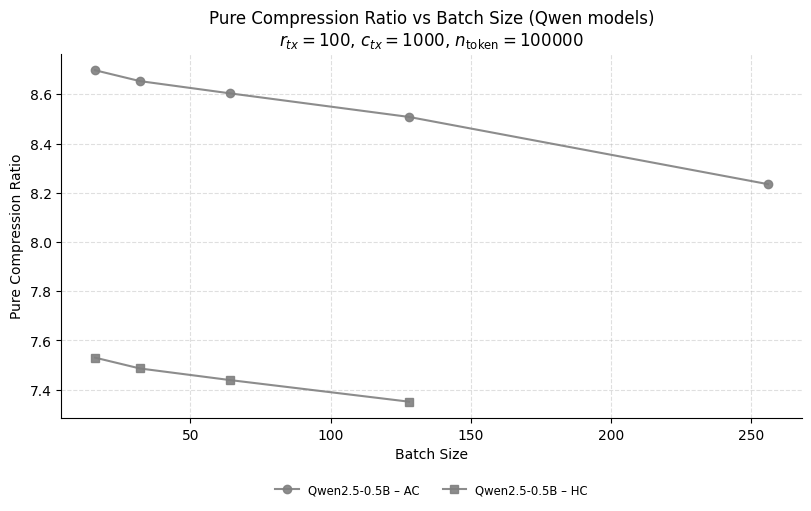

In [32]:
y_col = "pure_compression_factor"
x_col = "batch_size"

save_path = "pure_compression_vs_batch_size_qwen.png"

# ============================================================
# Filter data
# ============================================================

df_plot = df.copy()

# keep base models only
df_plot = df_plot[df_plot["adapter_size_bytes"] == 0]

# keep Qwen models only
df_plot = df_plot[df_plot["model_name"].str.contains("Qwen", na=False)]

# keep necessary columns
df_plot = df_plot[
    ["run_key", "encoding", "model_name", "batch_size", y_col]
]

df_plot = df_plot.dropna(subset=["batch_size", y_col])

# ============================================================
# Setup figure
# ============================================================

fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

# ============================================================
# Plot results
# ============================================================

for (model, enc), group in df_plot.groupby(["model_name", "encoding"]):
    group = group.sort_values("batch_size")

    ax.plot(
        group["batch_size"],
        group[y_col],
        marker=MARKER_BY_ENCODING.get(enc, "o"),
        color=COLOR_BY_MODEL.get(model, "gray"),
        label=f"{model} – {enc}",
        alpha=0.9
    )

# ============================================================
# Labels
# ============================================================

ax.set_xlabel("Batch Size")
ax.set_ylabel(pretty_label(y_col))

ax.set_title(
    f"{pretty_label(y_col)} vs Batch Size (Qwen models)\n"
    r"$r_{tx}=100$, $c_{tx}=1000$, $n_{\mathrm{token}}=100000$"
)

# ============================================================
# Grid styling
# ============================================================

ax.grid(True, linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ============================================================
# Legend
# ============================================================

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False,
    fontsize="small"
)

# ============================================================
# Save
# ============================================================

plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved plot to {save_path}")

plt.show()

### Plot results on different base models

KeyError: 'Qwen2.5-0.5B'

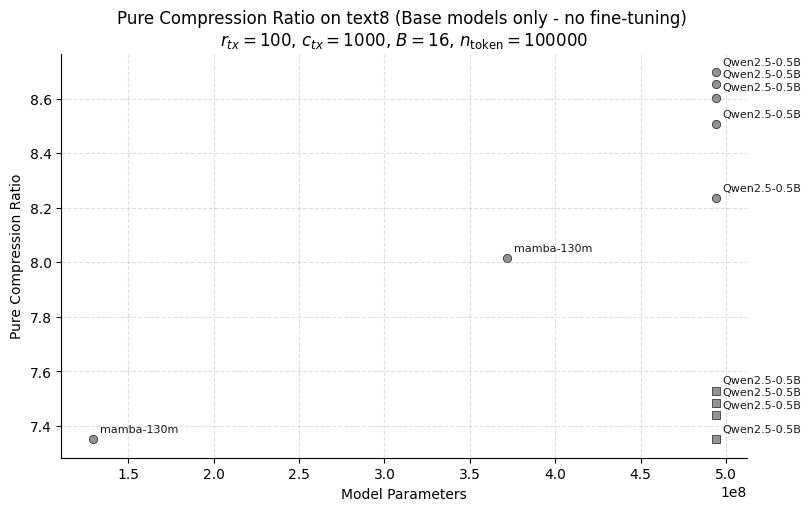

In [33]:
y_col = 'pure_compression_factor'
x_col = 'total_params'
save_path = "pure_compression_factor_vs_total_params.png"
filter = 'batch_size'
filter_value = 16

df_plot = df[['run_key', 'rank', 'peft', 'encoding', 'adapter_params', y_col, filter, 'model_name']]

# keep only base models by removing all models with adapter_params or quantized models (assuming they have "quant" in run_key)
df_plot = df[(df['adapter_size_bytes'] == 0)] # & (~df_plot['run_key'].str.contains("quant", case=False))]
df_plot = df_plot.dropna(subset=["model_name"])  # Keep only allowed models

#df_plot = restrict_df(df_plot, filter, filter_value)

# --- Setup figure ---
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True) #dpi=200)

# --- Plot points ---
for _, r in df_plot.iterrows():
    if pd.isna(r[x_col]) or pd.isna(r[y_col]) or pd.isna(r['adapter_params']):
        continue

    x = r[x_col]
    y = r[y_col]

    ax.scatter(
        x,
        y,
        color=COLOR_BY_MODEL.get(r["model_name"], "gray"),  
        marker=MARKER_BY_ENCODING.get(r["encoding"], "o"),
        alpha=0.85,
        edgecolor='black',
        linewidth=0.5
    )

    # --- Add model name label ---
    ax.annotate(
        r["model_name"],       # label with model name
        (x, y),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
        alpha=0.9,
    )

# --- Labels ---
ax.set_xlabel(pretty_label(x_col))
ax.set_ylabel(pretty_label(y_col))

ax.set_title(
    f"{pretty_label(y_col)} on text8 (Base models only - no fine-tuning) \n"
    rf"$r_{{tx}} = 100$, $c_{{tx}} = 1000$, $B={filter_value}$, $n_{{\mathrm{{token}}}} = 100000$"
)
# --- Grid styling ---
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ============================================================
# Legends
# ============================================================
# --- Create combined legend handles ---
legend_handles = []

# Add model color handles (circle markers)
for model, color in COLOR_BY_MODEL.items():
    legend_handles.append(
        Line2D([], [], color=color, marker='o', linestyle='None',
               markersize=7, label=f"Model: {model}")
    )

# Add encoding shape handles (gray color to distinguish shape)
for enc, marker in MARKER_BY_ENCODING.items():
    legend_handles.append(
        Line2D([], [], color='gray', marker=marker, linestyle='None',
               markersize=7, label=f"Encoding: {enc}")
    )

# Get all unique models in the plot, create handles only for these models
models_in_plot = df_plot['model_name'].unique()
legend_handles = [
    Line2D([], [], color=COLOR_BY_MODEL[model], marker='o', linestyle='None', markersize=7, label=f"Model: {model}")
    for model in models_in_plot]

# --- Add a single merged legend ---
ax.legend(handles=legend_handles,
          loc='upper center',
          bbox_to_anchor=(0.5, -0.15),
          ncol=3,
          frameon=False,
          fontsize='small')

# --- Save figure ---
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"Saved plot to {save_path}")

plt.show()

### Compression quality per model parameters for all model types (incl. with adapters) for AC only

Saved plot to comp_per_param_vs_adapter_params.png


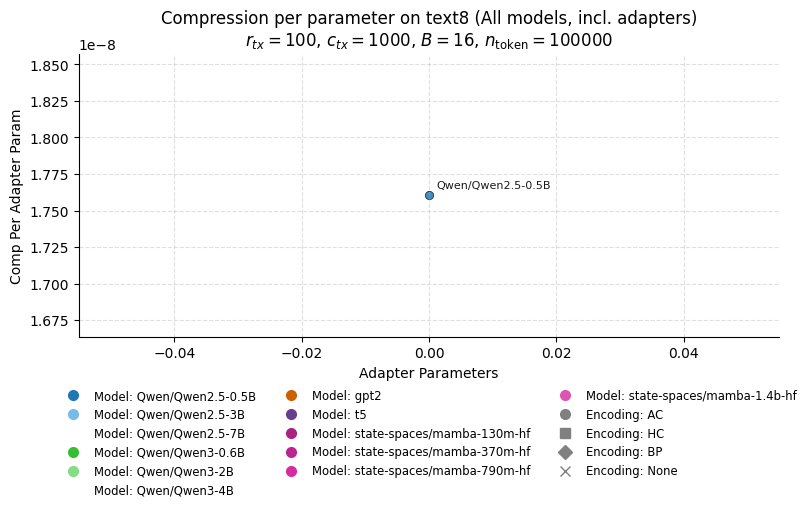

Index(['run_key', 'chunk_length', 'chunk_size', 'original_size_bytes',
       'arithmetic_code_size_bytes', 'bitmap_size_bytes', 'final_size_bytes',
       'pure_compression_factor', 'compression_factor', 'input_tokens_count',
       'entropy', 'total_compression_time', 'tokenize_time',
       'compression_time', 'inference_time', 'ac_time', 'data_copy_time',
       'softmax_time', 'throughput_tokens_per_sec',
       'throughput_kibibytes_per_sec', 'inference_throughput_tokens_per_sec',
       'inference_throughput_kibibytes_per_sec', 'total_params',
       'adapter_params', 'base_model_params', 'total_size_mb', 'mode',
       'model_name', 'context_length', 'retain_tokens', 'first_n_tokens',
       'use_kv_cache', 'text_input', 'reduce_tokens', 'batch_size', 'engine',
       'encoding', 'is_seq2seq', 'peft', 'rank', 'is_mamba',
       'adapter_size_bytes', 'base_model_size_bytes', 'pure_comp_factor',
       'total_bytes', 'eff_comp_factor', 'comp_per_adapter_param'],
      dtype='str'

In [ ]:
# --- Copy dataframe to avoid modifying original ---
df_plot = df.copy()

# Filter for Batch Size = 16
df_plot = df_plot[df_plot['batch_size'] == 16]

# Filter for Adapter Size = 0 (base models only)
df_plot = df_plot[df_plot['adapter_size_bytes'] == 0]

# Filter for AC encoding only
df_plot = df_plot[df_plot['encoding'] == 'AC']


# --- Compute compression per adapter param safely --
df_plot['comp_per_adapter_param'] = df_plot['pure_compression_factor'] / (df_plot['total_params'] + 1e-9)
#TODO: fix normalization 

y_col = 'comp_per_adapter_param'
x_col = 'adapter_params'
save_path = "comp_per_param_vs_adapter_params.png"

filter = 'batch_size'
filter_value = 16

# --- Apply batch size filter ---
df_plot = df_plot[df_plot[filter] == filter_value]
df_plot = df_plot[df_plot['encoding'] == 'AC']  # Keep only AC encoding for this plot

# --- Setup figure ---
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

# --- Plot points ---
for _, r in df_plot.iterrows():
    if pd.isna(r[x_col]) or pd.isna(r[y_col]):
        continue

    x = r[x_col]
    y = r[y_col]

    # Get color and marker
    color = COLOR_BY_MODEL.get(r.get("model_name", "Unknown"), "gray")
    marker = MARKER_BY_ENCODING.get(r.get("encoding", None), "o")

    ax.scatter(
        x,
        y,
        color=color,       # color = model type
        marker=marker,     # shape = encoding
        alpha=0.85,
        edgecolor='black',
        linewidth=0.5
    )

    # --- Annotate with model name ---
    ax.annotate(
        r.get("model_name", "Unknown"),
        (x, y),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
        alpha=0.9,
    )

# --- Labels ---
ax.set_xlabel(pretty_label(x_col))
ax.set_ylabel(pretty_label(y_col))
ax.set_title(
    f"Compression per parameter on text8 (All models, incl. adapters)\n"
    rf"$r_{{tx}} = 100$, $c_{{tx}} = 1000$, $B={filter_value}$, $n_{{\mathrm{{token}}}} = 100000$"
)

# --- Grid styling ---
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Create merged legend ---
legend_handles = []

# Model colors
for model, color in COLOR_BY_MODEL.items():
    legend_handles.append(Line2D([], [], color=color, marker='o', linestyle='None',
                                 markersize=7, label=f"Model: {model}"))

# Encoding markers
for enc, marker in MARKER_BY_ENCODING.items():
    legend_handles.append(Line2D([], [], color='gray', marker=marker, linestyle='None',
                                 markersize=7, label=f"Encoding: {enc}"))

ax.legend(handles=legend_handles,
          loc='upper center',
          bbox_to_anchor=(0.5, -0.15),
          ncol=3,
          frameon=False,
          fontsize='small')

# --- Save figure ---
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to {save_path}")
plt.show()


# sort df_plot values by run_key to ensure consistent order
df_plot = df_plot.sort_values(by='run_key').reset_index(drop=True)
df_plot.head(10)

# print colum names
print(df_plot.columns)
print(df_plot.first_n_tokens)


### Results on finetuning adapter

Saved plot to pure_compression_factor_vs_rank.png


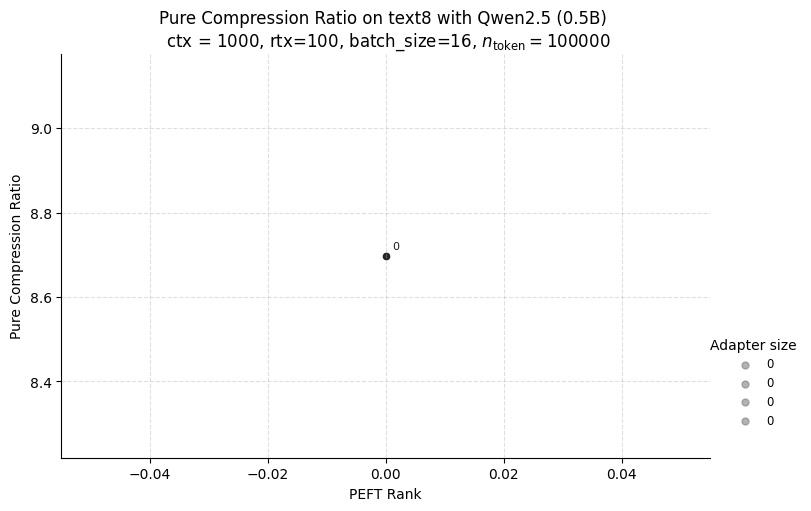

In [ ]:
y_col = 'pure_compression_factor'
save_path = "pure_compression_factor_vs_rank.png"
filter = 'batch_size'
filter_value = 16

# --- Setup figure with automatic layout ---
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True) #dpi=200)

# --- Define color/marker mappings ---
#COLOR_BY_PEFT = {None: "tab:gray", "lora": "tab:blue", "vera": "tab:orange"}

# --- Normalize marker size by adapter_params ---
param_min = df['adapter_params'].min()
param_max = df['adapter_params'].max()

def size_fn(x):
    return 25 + 200 * (x - param_min) / (param_max - param_min + 1e-9)

df['marker_size'] = df['adapter_params'].apply(size_fn)

def restrict_df(df, filter, value):
    if filter not in df.columns:
        print(f"Warning: filter column '{filter}' not found in DataFrame. No filtering applied.")
        return df
    return df[df[filter] == value]

df = restrict_df(df, filter, filter_value)
df = restrict_df(df, 'encoding', 'AC')  # Keep only AC encoding for this plot

# --- Plot points ---
for _, r in df.iterrows():
    if pd.isna(r['rank']) or pd.isna(r[y_col]) or pd.isna(r['adapter_params']):
        continue

    x = r['rank']
    y = r[y_col]

    ax.scatter(
        x,
        y,
        color=COLOR_BY_PEFT.get(r["peft"], "black"),
        marker=MARKER_BY_ENCODING.get(r["encoding"], "o"),
        s=r['marker_size'],
        alpha=0.85,
        edgecolor='black',
        linewidth=0.5
    )

    # --- Add rank label ---
    ax.annotate(
        x,          # convert to string
        (x, y),                  # position
        textcoords="offset points",
        xytext=(5, 5),           # small offset to avoid overlap
        fontsize=8,
        alpha=0.9,
    )

# --- Labels ---
ax.set_xlabel("PEFT Rank")
ax.set_ylabel(pretty_label(y_col))
ax.set_title(f"{pretty_label(y_col)} on text8 with Qwen2.5 (0.5B) \n ctx = 1000, rtx=100, {filter}={filter_value}, $n_{{\\text{{token}}}} = 100000$")

# --- Grid styling ---
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ============================================================
# Legends
# ============================================================

# --- Color legend (PEFT type) ---
color_legend = [
    Line2D([], [], color=color, marker='o', linestyle='None',
           markersize=7, label=f"PEFT: {peft}" if peft else "No PEFT")
    for peft, color in COLOR_BY_PEFT.items()
]

# --- Marker legend (Encoding) ---
marker_legend = [
    Line2D([], [], color='black', marker=marker, linestyle='None',
           markersize=7, label=f"Encoding: {enc}")
    for enc, marker in MARKER_BY_ENCODING.items()
    if enc is not None
]

# --- Bubble size legend ---
size_values = np.linspace(param_min, param_max, 4)
size_legend = [
    plt.scatter([], [], s=size_fn(val), color='gray', alpha=0.6,
                label=f"{int(val):,}")
    for val in size_values
]

# Add legends separately so they don't override each other
legend1 = ax.legend(
    handles=color_legend + marker_legend,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
)

ax.add_artist(legend1)

legend2 = ax.legend(handles=size_legend,
                    title="Adapter size",
                    loc='lower right',
                    bbox_to_anchor=(1.15, 0.05),
                    ncol = 1,
                    frameon=False,
                    fontsize='small')

# --- Save figure ---
#if save_path:
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to {save_path}")

plt.show()

KeyError: 'effective_compression_factor'

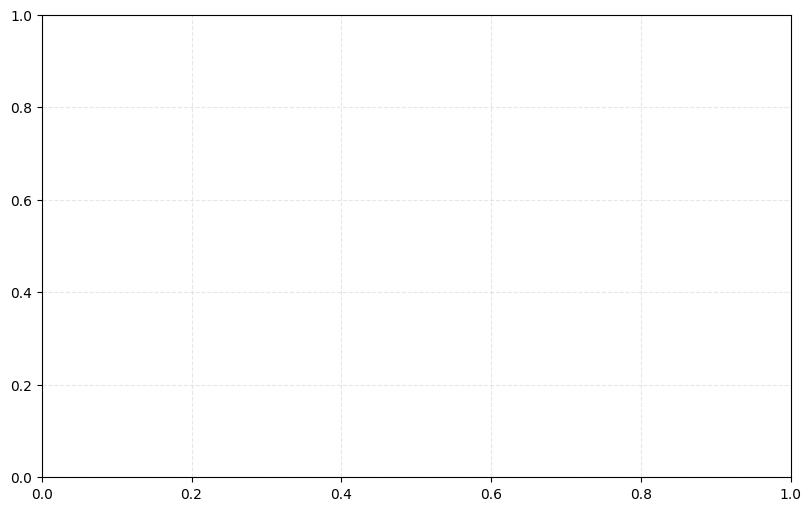

In [ ]:
y_col = "effective_compression_factor"
save_path = "effective_compression_factor_vs_rank.png"

# --- Setup figure with automatic layout ---
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True) #dpi=200)

# --- Define color/marker mappings ---
#COLOR_BY_PEFT = {None: "tab:gray", "lora": "tab:blue", "vera": "tab:orange"}

# --- Normalize marker size by adapter_params ---
param_min = df['adapter_params'].min()
param_max = df['adapter_params'].max()

def size_fn(x):
    return 25 + 200 * (x - param_min) / (param_max - param_min + 1e-9)

df['marker_size'] = df['adapter_params'].apply(size_fn)

# --- Plot points ---
for _, r in df.iterrows():
    if pd.isna(r['rank']) or pd.isna(r[y_col]) or pd.isna(r['adapter_params']):
        continue

    x = r['rank']
    y = r[y_col]

    ax.scatter(
        x,
        y,
        color=COLOR_BY_PEFT.get(r["peft"], "black"),
        marker=MARKER_BY_ENCODING.get(r["encoding"], "o"),
        s=r['marker_size'],
        alpha=0.85,
        edgecolor='black',
        linewidth=0.5
    )

    # --- Add rank label ---
    ax.annotate(
        x,          # convert to string
        (x, y),                  # position
        textcoords="offset points",
        xytext=(5, 5),           # small offset to avoid overlap
        fontsize=8,
        alpha=0.9,
    )

# --- Labels ---
ax.set_xlabel("PEFT Rank")
ax.set_ylabel(pretty_label(y_col))
ax.set_title(f"{pretty_label(y_col)} on text8 with Qwen2.5 (0.5B) \n ctx = 1000, rtx=100, B = 16, $n_{{\\text{{token}}}} = 100000$")

# --- Grid styling ---
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ============================================================
# Legends
# ============================================================

# --- Color legend (PEFT type) ---
color_legend = [
    Line2D([], [], color=color, marker='o', linestyle='None',
           markersize=7, label=f"PEFT: {peft}" if peft else "No PEFT")
    for peft, color in COLOR_BY_PEFT.items()
]

# --- Marker legend (Encoding) ---
marker_legend = [
    Line2D([], [], color='black', marker=marker, linestyle='None',
           markersize=7, label=f"Encoding: {enc}")
    for enc, marker in MARKER_BY_ENCODING.items()
    if enc is not None
]

# --- Bubble size legend ---
size_values = np.linspace(param_min, param_max, 4)
size_legend = [
    plt.scatter([], [], s=size_fn(val), color='gray', alpha=0.6,
                label=f"{int(val):,}")
    for val in size_values
]

# Add legends separately so they don't override each other
legend1 = ax.legend(
    handles=color_legend + marker_legend,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,
)

ax.add_artist(legend1)

legend2 = ax.legend(handles=size_legend,
                    title="Adapter size",
                    loc='lower right',
                    bbox_to_anchor=(1.15, 0.05),
                    ncol = 1,
                    frameon=False,
                    fontsize='small')

# --- Save figure ---
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved plot to {save_path}")

plt.show()

#TODO: fix color legend (no grey yet)
#TODO: verify for non-adapter models effective compression factor  

### Results on Quantization